# Gráficos de error

Muchas veces, cuando desarrollamos un proyecto de Ciencia de Datos o Machine Learning, los datos que procesamos pueden tener algunas de estas características:

- Provienen de una medición obtenida a partir de un sensor (por ejemplo de temperatura o de presión) y puede haber discrepancias con el valor exacto que se quiere medir
- La variable medida no es constante y en su lugar se encuentra dentro de un cierto rango de valores (por ejemplo la temperatura durante un mes en particular o el rango de valores dentro de los cuales oscila una acción en la bolsa)
- La predicción generada por un modelo de regresión de *Machine Learning* no es exacta (en comparación con los valores de referencia) y los errores pueden estar dentro de cierto rango de valores.

En estos casos resulta útil generar una gráfica que permita visualizar esta variabilidad o incertidumbre en los datos que estamos procesando o prediciendo. En estos casos se sugiere usar precisamente un gráfico de error, que es precisamente el tema de esta lección.

En particular veremos cómo usar las funciones `errorbar` y `fill_between` de Matplotlib para generar diferentes tipos de gráficos de error, dependiendo de si nuestros datos son continuos o discretos o de si tenemos "muchos" o "pocos" datos por visualizar.

## 1. Gráficos de error con `errorbar`

Lo usamos cuando queremos generar un gráfico de error pero la cantidad de datos es limitada (o simplemente son datos categóricos).

Por ejemplo, supongamos que queremos crear un clasificador para un set de datos en particular, y que medimos su desempeño usando la exactitud (número de datos clasificados correctamente / número total de datos a clasificar).

Y supongamos que no sabemos qué tipo de modelo será el más adecuado para esta tarea (Árbol de clasificación, bosque aleatorio, Red Neuronal, Máquina de Soporte Vectorial, etc.) así que entrenamos 6 diferentes modelos.

Por cada modelo evaluamos:

- Su exactitud promedio
- Su exactitud máxima
- Su exactitud mínima

El resultado se encuentra en el archivo *errorbar_dataset.csv*. ¿Cuál modelo sería el más adecuado?

Como tenemos "pocos" datos (sólo 6 modelos) podemos generar un gráfico de error con `errorbar` que nos muestre por cada modelo su promedio y sus rangos máximo y mínimo y a partir de esta gráfica podremos decidir cuál sería el modelo más adecuado:

In [2]:
# Comencemos importando las librerías necesarias
import matplotlib.pyplot as plt
import pandas as pd

# Y realicemos la lectura del dataset
df = pd.read_csv('errorbar_dataset.csv')
df

,Modelo,Exactitud promedio,Exactitud mínima,Exactitud máxima
0,1,0.82,0.80,0.86
1,2,0.87,0.81,0.90
2,3,0.93,0.91,0.95
3,4,0.91,0.81,0.98
4,5,0.75,0.72,0.78
5,6,0.63,0.61,0.64


In [3]:
# Antes de graficar debemos calcular los errores de cada modelo
# con respecto a su exactitud promedio
df['Err_max'] = df['Exactitud máxima']-df['Exactitud promedio']
df['Err_min'] = df['Exactitud promedio']-df['Exactitud mínima']
df

,Modelo,Exactitud promedio,Exactitud mínima,Exactitud máxima,Err_max,Err_min
0,1,0.82,0.80,0.86,0.04,0.02
1,2,0.87,0.81,0.90,0.03,0.06
2,3,0.93,0.91,0.95,0.02,0.02
3,4,0.91,0.81,0.98,0.07,0.10
4,5,0.75,0.72,0.78,0.03,0.03
5,6,0.63,0.61,0.64,0.01,0.02


In [4]:
# Al igual que en la lección anterior, definamos un estilo para las gráficas, por ejemplo
# "seaborn-v0_8-whitegrid"

# Definir estilo de color (ejemplos interesantes: seaborn-whitegrid, fivethirtyeight, bmh, ggplot)
plt.style.use('seaborn-v0_8-whitegrid')

Y con esto ya podemos comenzar a generar la gráfica:

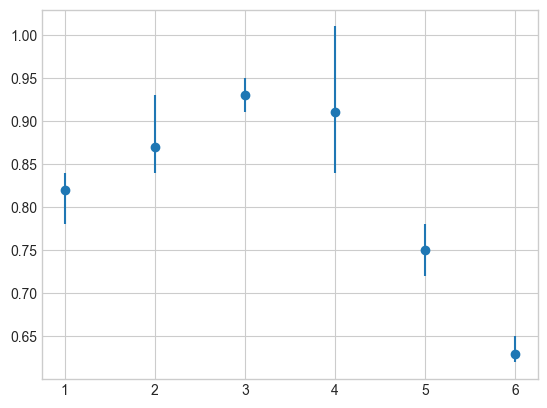

In [5]:
# Creemos los arreglos con los datos a graficar
x = df['Modelo']
y = df['Exactitud promedio']
errores = [df['Err_max'], df['Err_min']]

# Y generemos una primera gráfica
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr = errores, fmt='o');

Vemos que la gráfica genera, por cada dato, un punto (indicando el valor promedio de la exactitud de cada modelo) y una línea que se extiende dentro del rango de error correspondiente.

El parámetro `fmt` (*format*) usado anteriormente permite definir el formato de cada punto de datos y de las líneas que interconectan cada par de datos consecutivos.

Por ejemplo, al usar `fmt = 'o'` como en el caso anterior le indicamos a Matplotlib que queremos marcar cada punto con un círculo y que no queremos que dibuje una línea conectora.

Si por ejemplo queremos interconectar cada par de puntos con una línea punteada, usamos `fmt = 'o--'`:

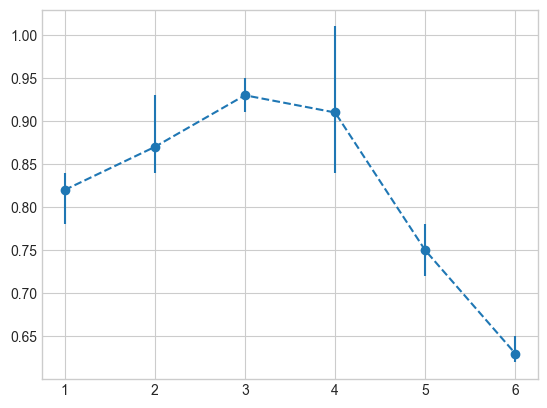

In [6]:
# Por ejemplo, podemos generar líneas punteadas en luga de líneas contínuas:
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr = errores, fmt='o--');

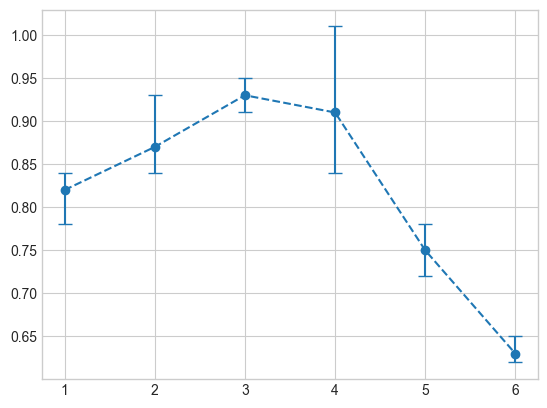

In [9]:
# Y podemos por ejemplo agregar barras horizontales a cada línea de error usando
# "capsize"
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr = errores, fmt='o--', capsize=5);

Y como todo en Matplotlib, podemos controlar cada uno de los elementos de la gráfica.

En este caso generaremos variables que contengan cada objeto (marcadores, barras y caps) y los personalizaremos:

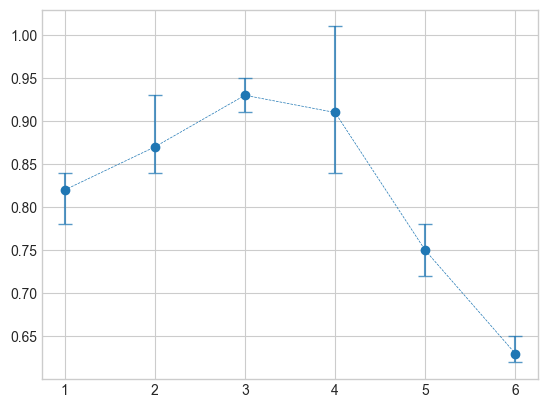

In [10]:
# Generemos la gráfica con estas características:
# - Punto central de color azul (fmt='o')
# - Líneas de error del mismo color azul pero con alpha = 0.5

# Generación gráfica básica
fig, ax = plt.subplots()
marcadores, caps, barras = ax.errorbar(x, y, yerr = errores, fmt='o--', capsize=5)

# Personalización elementos individuales
for cap in caps:
    cap.set_alpha(0.75)
for barra in barras:
    barra.set_alpha(0.75)
marcadores.set_linewidth(0.5)

Y para finalizar agregemos etiquetas a los ejes y título a la gráfica:

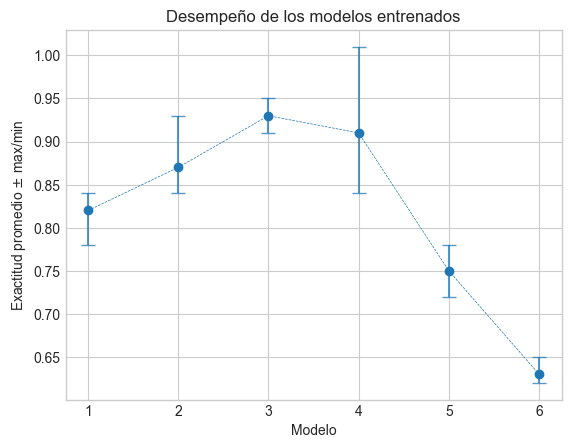

In [12]:
# Generación gráfica básica
fig, ax = plt.subplots()
marcadores, caps, barras = ax.errorbar(x, y, yerr = errores, fmt='o--', capsize=5)

# Personalización elementos individuales
for cap in caps:
    cap.set_alpha(0.75)
for barra in barras:
    barra.set_alpha(0.75)
marcadores.set_linewidth(0.5)

# Título y etiquetas
ax.set_xlabel('Modelo')
ax.set_ylabel('Exactitud promedio $\pm$ max/min')
ax.set_title('Desempeño de los modelos entrenados');

Y la gráfica anterior nos permite observar que el modelo 3 es el que tiene el mejor desempeño, no sólo por su valor promedio (0.93) sino también porque su rango de variación es el mínimo (0.91 a 0.95).

## 2. Gráficos de error con `fill_between`

Lo usamos cuando queremos dibujar un gráfico de error pero tenemos muchos datos (cientos o miles) o si estos datos son continuos (por ejemplo series de tiempo).

### 2.1. Ejemplo práctico

Supongamos que tenemos una serie de tiempo que contiene la temperatura en °C de una región geográfica en particular. Esta serie de tiempo ha sido adquirida en intervalos de 1 hora para un período de 1 año (de enero 1 a diciembre 31)

Y supongamos que entrenamos un modelo de Machine Learning que busca predecir la temperatura durante el siguiente mes (es decir del 1 al 31 de enero del siguiente año).

Es de esperar que este modelo entrenado genere predicciones con un **alto grado de certidumbre** durante los primeros días del mes de enero, pero a medida que avanza el tiempo en las predicciones este grado de certidumbre se reduce.

Una forma de medir este **grado de incertidumbre** es a través de lo que se conoce en estadística como el **intervalo de confianza** que es simplemente el rango de valores dentro de los cuales se estima que estará el valor a predecir (en este caso la temperatura).

Este intervalo de confianza generalmente se describe como un porcentaje (80%, 90%, 95%). Por ejemplo, un intervalo de confianza del 95% indica que la temperatura puede estar entre 5 y 7 °C para el día 3 de enero a las 10:00 am quiere decir que podemos tener una certeza del 95% de que para ese día y a esa hora la temperatura estará precisamente entre 5 y 7 °C.

Así, si graficamos para cada hora del mes de enero tanto la predicción de la temperatura promedio esperada junto con su correspondiente intervalo de confianza, podremos ver qué tan fiables serán las predicciones generadas por el modelo.

Asumamos que en el archivo *fill_between_dataset.csv* se encuentran las predicciones e intervalos de confianza para cada hora desde el 1 hasta el 31 de enero. La idea entonces es generar la gráfica de error correspondiente para así analizar la fiabilidad del modelo:

In [13]:
# Comencemos por leer el dataset
data = pd.read_csv('fill_between_dataset.csv')
data

,Hora,Temp. predicha (°C),CI 95% (°C)
0,1,5.5,0.51
1,2,5.5,0.51
2,3,5.5,0.51
3,4,5.5,0.51
4,5,5.5,0.52
...,...,...,...
739,740,5.5,2.24
740,741,5.5,2.25
741,742,5.5,2.25
742,743,5.5,2.25


Por ejemplo, para la primera hora se tiene:

- Temp. predicha (°C): 5.5
- CI 95% (°C): 0.51

Lo anterior quiere decir que con una certeza del 95% podremos decir que en la primera hora la temperatura estará entre 5.5 - 0.51 = 4.99 °C y 5.5 + 0.51 = 6.01 °C.

Hagamos una gráfica simple de la temperatura promedio predicha por el modelo (columna *Temp. predicha (°C)*):

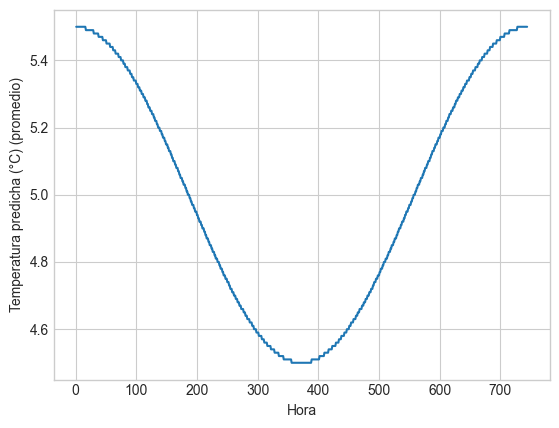

In [14]:
# Extracción arreglo temperatura
temps = data['Temp. predicha (°C)']
horas = data['Hora']

# Generación gráfica de líneas
fig, ax = plt.subplots()
ax.plot(horas, temps)
ax.set_xlabel('Hora')
ax.set_ylabel('Temperatura predicha (°C) (promedio)');

Al dibujar sólo la temperatura predicha no tenemos una idea clara de la fiabilidad del modelo al realizar las predicciones.

Para tener una idea precisa de esta fiabilidad, debemos graficar además los intervalos de confianza. Hagamos esta gráfica usando inicialmente la función `errorbar` vista hace un momento:

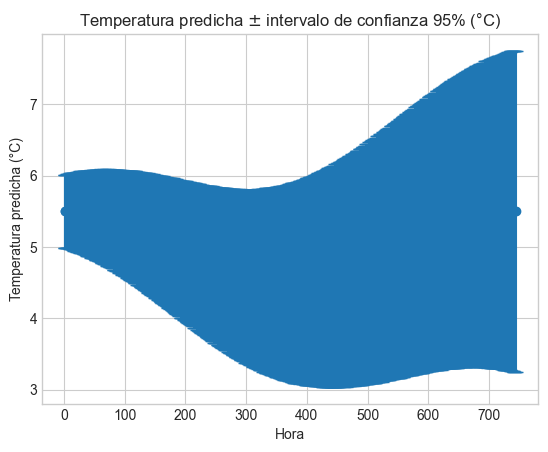

In [15]:
# Extracción de intervalos de confianza
ci = data['CI 95% (°C)']

# Generación gráfica básica
fig, ax = plt.subplots()
ax.errorbar(horas, temps, yerr = ci, fmt='o--', capsize=5)

# Título y etiquetas
ax.set_xlabel('Hora')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title('Temperatura predicha $\pm$ intervalo de confianza 95% (°C)');

El problema de usar `errorbar` en este caso es que el elevado número de datos impide visualizar claramente el valor promedio de temperatura y los intervalos de confianza en cada hora de predicción.

Veamos cómo generar una mejor visualización usando `fill_between`. Primero dibujemos la temperatura promedio así como las temperaturas máxima y mínima predichas:

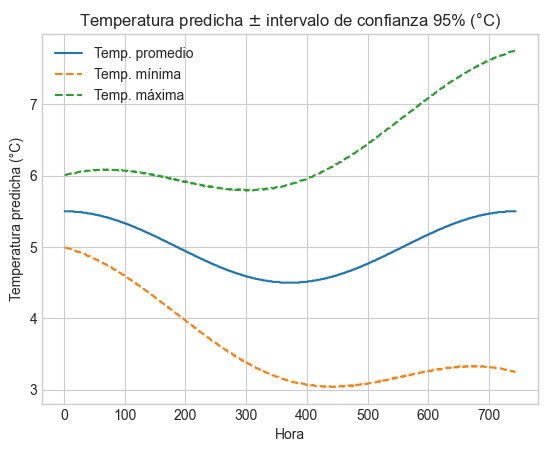

In [16]:
# Temperaturas mínima y máxima predichas
temps_mins = temps - ci
temps_maxs = temps + ci

# Gráficos de línea de las temperaturas promedio, máxima y mínima predichas
fig, ax = plt.subplots()
ax.plot(horas, temps,label='Temp. promedio')
ax.plot(horas, temps_mins, '--', label='Temp. mínima')
ax.plot(horas, temps_maxs, '--', label='Temp. máxima');
ax.legend()

# Título y etiquetas
ax.set_xlabel('Hora')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title('Temperatura predicha $\pm$ intervalo de confianza 95% (°C)');

Un poco mejor. Aunque podemos evitar tantos elementos cambiando los colores de las curvas superior e inferior por el color azul por defecto y eliminando la leyenda:

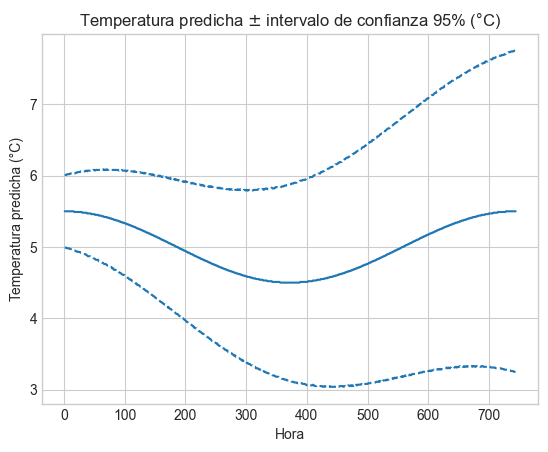

In [17]:
# Gráficos de línea de las temperaturas promedio, máxima y mínima predichas
fig, ax = plt.subplots()
ax.plot(horas, temps)
ax.plot(horas, temps_mins, '--', color = 'C0') # color = 'C0': primer color del ciclo de colores
ax.plot(horas, temps_maxs, '--', color = 'C0')

# Título y etiquetas
ax.set_xlabel('Hora')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title('Temperatura predicha $\pm$ intervalo de confianza 95% (°C)');

Un poco mejor. Ahora sí usemos `fill_between` para rellenar las áreas entre las temperaturas mínimas y máximas:

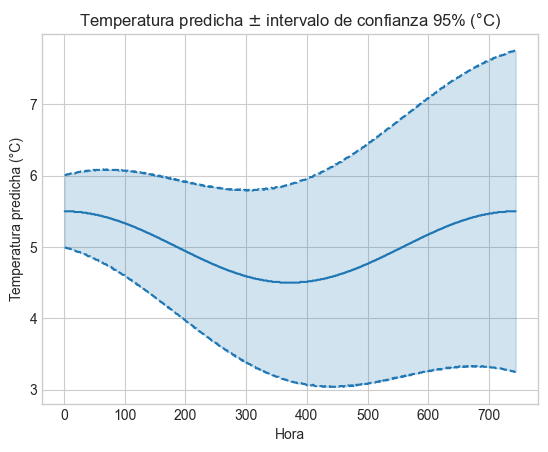

In [18]:
# Gráficos de línea de las temperaturas promedio, máxima y mínima predichas
fig, ax = plt.subplots()
ax.plot(horas, temps)
ax.plot(horas, temps_mins, '--', color = 'C0') # color = 'C0': primer color del ciclo de colores
ax.plot(horas, temps_maxs, '--', color = 'C0')

# Fill between: simplemente especificamos los rangos máximo y mínimo, el color y la transparencia
ax.fill_between(horas, temps_maxs, temps_mins, color="C0", alpha=0.2)

# Título y etiquetas
ax.set_xlabel('Hora')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title('Temperatura predicha $\pm$ intervalo de confianza 95% (°C)');

Mucho mejor. Cambiemos el grosor de las líneas punteadas y el nivel de transparencia del área rellenada:

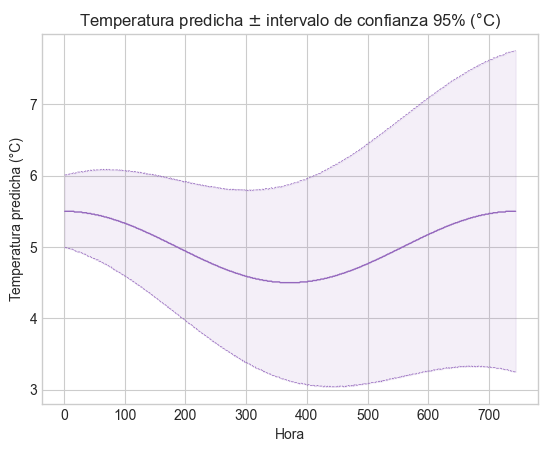

In [19]:
# Gráficos de línea de las temperaturas promedio, máxima y mínima predichas
color = 'C4' # Variable que permite elegir la tonalidad de la gráfica de error
fig, ax = plt.subplots()
ax.plot(horas, temps, color=color, lw=1.0)
ax.plot(horas, temps_mins, '--', color = color, lw=0.5)
ax.plot(horas, temps_maxs, '--', color = color, lw=0.5)

# Fill between: simplemente especificamos los rangos máximo y mínimo, el color y la transparencia
ax.fill_between(horas, temps_maxs, temps_mins, color=color, alpha=0.1)

# Título y etiquetas
ax.set_xlabel('Hora')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title('Temperatura predicha $\pm$ intervalo de confianza 95% (°C)');

!Muy bien! Con pocas líneas de código generamos una gráfica de error que permite entender fácilmente el desempeño del modelo al momento de realizar predicciones.

Por ejemplo:

- En las primeras horas predichas (0 a 100 aproximadamente) el intervalo de confianza (con un grado de fiabilidad del 95%) es de entre 0.5 y 0.6 °C.
- Pero a medida que avanza el tiempo este intervalo de confianza se incrementa hasta más de 2°C. (en la hora 740)

Lo anterior quiere decir que las predicciones empeoran a medida que avanza el número de horas predichas.